# Pearls AQI Predictor — Exploratory Data Analysis
Trends, seasonality, autocorrelation and pollutant relationships used to design features.

Runs offline on the synthetic generator; with API keys it reads the live feature store.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.feature_pipeline.data_fetcher import DataFetcher
from src.feature_pipeline.feature_engineer import engineer_features

df = DataFetcher().fetch_history('london', days=90)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape); df.head()

(2160, 13)


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,humidity,pressure,wind_speed
0,2026-03-08 09:00:00+00:00,london,24.8,6.9,10.4,38.9,22.7,6.9,0.43,16.1,42.0,1019.0,5.6
1,2026-03-08 10:00:00+00:00,london,22.1,9.3,12.7,49.1,40.4,16.0,0.94,17.7,44.0,1003.0,2.1
2,2026-03-08 11:00:00+00:00,london,32.9,13.3,21.4,38.2,35.0,14.2,0.89,20.8,50.0,1011.0,5.0
3,2026-03-08 12:00:00+00:00,london,34.7,16.5,23.9,60.0,21.9,11.2,0.88,23.9,62.0,1027.0,5.7
4,2026-03-08 13:00:00+00:00,london,30.1,21.0,34.8,40.3,47.2,8.4,0.58,22.2,67.0,1016.0,2.8


## 1. AQI over time + distribution

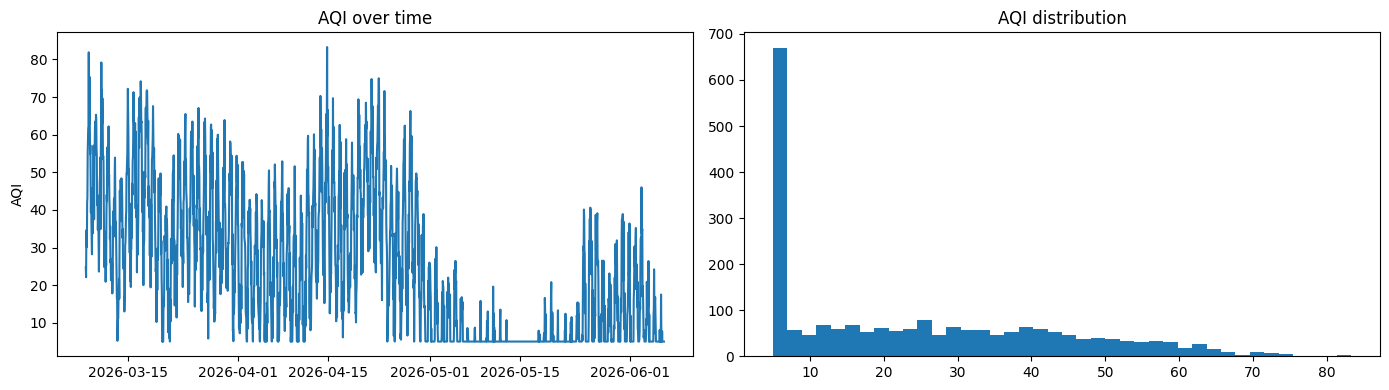

count    2160.000000
mean       24.396667
std        18.765345
min         5.000000
25%         5.000000
50%        20.550000
75%        38.900000
max        83.300000
Name: aqi, dtype: float64

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(df['timestamp'], df['aqi']); ax[0].set_title('AQI over time'); ax[0].set_ylabel('AQI')
ax[1].hist(df['aqi'], bins=40); ax[1].set_title('AQI distribution')
plt.tight_layout(); plt.show()
df['aqi'].describe()

## 2. Daily + weekly seasonality

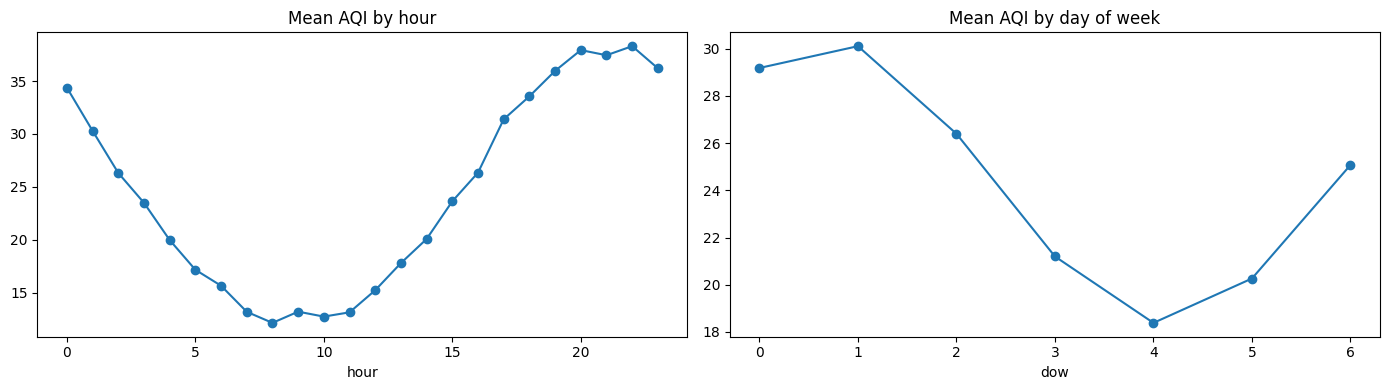

In [3]:
df['hour'] = df['timestamp'].dt.hour
df['dow']  = df['timestamp'].dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df.groupby('hour')['aqi'].mean().plot(ax=ax[0], marker='o', title='Mean AQI by hour')
df.groupby('dow')['aqi'].mean().plot(ax=ax[1], marker='o', title='Mean AQI by day of week')
plt.tight_layout(); plt.show()

## 3. Autocorrelation — motivates lag/rolling features

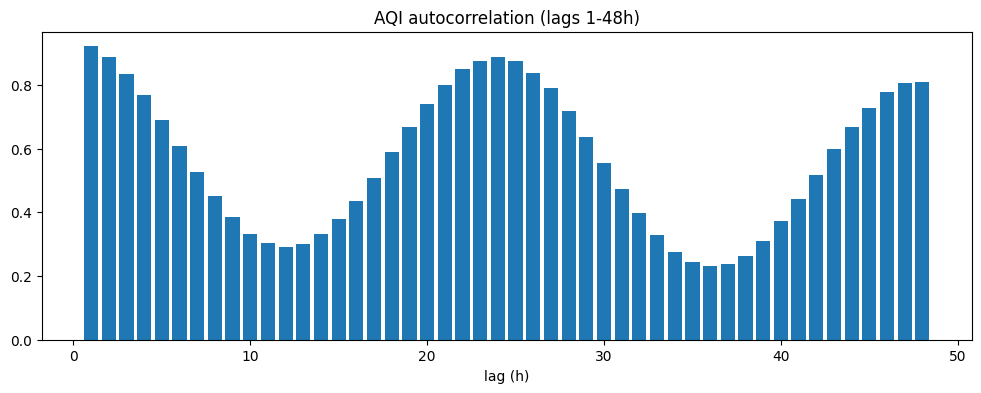

In [4]:
lags = range(1, 49)
acf = [df['aqi'].autocorr(lag=l) for l in lags]
plt.figure(figsize=(12, 4)); plt.bar(list(lags), acf)
plt.title('AQI autocorrelation (lags 1-48h)'); plt.xlabel('lag (h)'); plt.show()

## 4. Pollutant + weather correlations

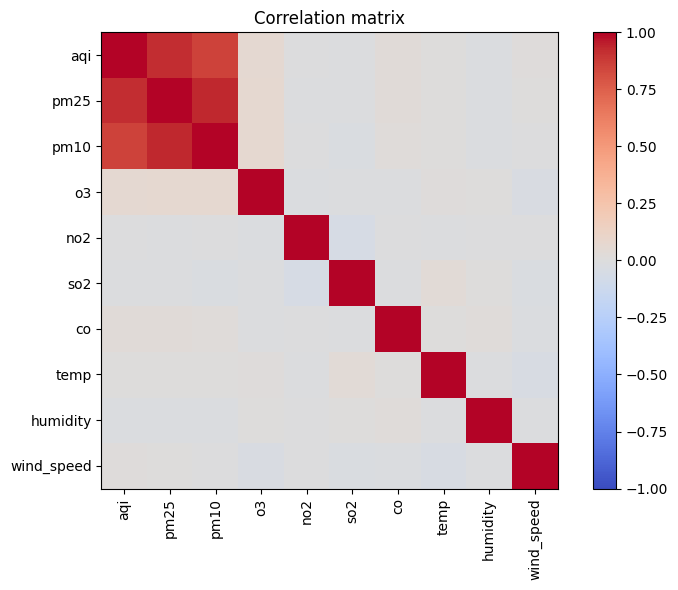

aqi           1.000000
pm25          0.916830
pm10          0.859274
o3            0.061435
co            0.023914
wind_speed    0.014038
temp          0.006841
no2          -0.005018
so2          -0.011509
humidity     -0.018520
Name: aqi, dtype: float64

In [5]:
cols = ['aqi','pm25','pm10','o3','no2','so2','co','temp','humidity','wind_speed']
corr = df[cols].corr()
plt.figure(figsize=(8, 6)); plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=90); plt.yticks(range(len(cols)), cols)
plt.colorbar(); plt.title('Correlation matrix'); plt.tight_layout(); plt.show()
corr['aqi'].sort_values(ascending=False)

## 5. Engineered feature preview

In [6]:
feat = engineer_features(df)
print('engineered columns:', len(feat.columns))
feat[['timestamp','aqi','aqi_lag_1','aqi_roll_mean_24','aqi_change_rate','wind_dispersion']].tail()

engineered columns: 38


,timestamp,aqi,aqi_lag_1,aqi_roll_mean_24,aqi_change_rate,wind_dispersion
2155,2026-06-06 04:00:00+00:00,5.0,5.0,5.9,0.0,1.384615
2156,2026-06-06 05:00:00+00:00,5.0,5.0,5.9,0.0,0.188679
2157,2026-06-06 06:00:00+00:00,5.0,5.0,5.9,0.0,0.204082
2158,2026-06-06 07:00:00+00:00,5.0,5.0,5.9,0.0,0.720588
2159,2026-06-06 08:00:00+00:00,5.0,5.0,5.9,0.0,0.250000


### Takeaways
- Strong daily (afternoon peak) + weekly cycles → cyclical encodings.
- High short-lag autocorrelation → lag_{1..24} + rolling stats are the dominant predictors.
- pm2.5 is the primary AQI driver → confirms EPA-breakpoint backfill.
- Per-city scale differences → train one model per city.